<a href="https://colab.research.google.com/github/Isaq0711/processamento-sinais-I/blob/main/aula-03/codigo/aula_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP3 — Transformada z
**GELE7317 — Processamento de Sinais I** — Prof. Rafael S. Chaves

Resolução das questões da Atividade Prática 3: resposta em frequência,
diagrama de polos e zeros, filtragem, projeto de filtros de
recuperação (inversos) e aproximações FIR.

> Rode as células em ordem. As Questões 2–3 dependem de `handel.wav`
> lido na célula de leitura de dados.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import freqz, lfilter
from IPython.display import Audio, display
import os

PASTA_DADOS = "dados"  # ajuste para o caminho onde está o handel.wav

# No Google Colab, use o bloco abaixo para enviar o arquivo de dados:
# from google.colab import files
# uploaded = files.upload()  # selecione handel.wav
# PASTA_DADOS = "."

In [2]:
def ler_wav(nome_arquivo):
    """Lê um .wav da pasta PASTA_DADOS e normaliza para [-1, 1]."""
    fs, x = wavfile.read(os.path.join(PASTA_DADOS, nome_arquivo))
    if x.ndim > 1:
        x = x[:, 0]
    if np.issubdtype(x.dtype, np.integer):
        x = x.astype(np.float64) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float64)
    return fs, x


def tocar(x, fs):
    """Reproduz um sinal de áudio inline (player do notebook)."""
    display(Audio(x, rate=fs))


def calculate_spectrum(x, fs, titulo="Espectro", xlim=None, escala_db=True):
    """Calcula e plota o espectro de magnitude (via FFT) de um sinal real x,
    amostrado a fs Hz. Retorna (freqs, mag).
    """
    n = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    mag = np.abs(X) / n

    plt.figure(figsize=(7, 3.5))
    if escala_db:
        plt.plot(freqs, 20 * np.log10(mag + 1e-12), linewidth=0.8)
        plt.ylabel("Magnitude (dB)")
    else:
        plt.plot(freqs, mag, linewidth=0.8)
        plt.ylabel("Magnitude")
    plt.xlabel("Frequência (Hz)")
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()
    return freqs, mag

In [3]:
def plotar_polos_zeros(b, a, titulo):
    """Plota o diagrama de polos e zeros de H(z) = B(z)/A(z) no plano z,
    com o círculo unitário como referência.
    """
    zeros = np.roots(b) if len(b) > 1 else np.array([])
    polos = np.roots(a) if len(a) > 1 else np.array([])

    theta = np.linspace(0, 2 * np.pi, 300)
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    if len(zeros) > 0:
        ax.scatter(zeros.real, zeros.imag, marker="o", facecolors="none",
                   edgecolors="tab:blue", s=90, label="zeros", linewidths=1.5)
    if len(polos) > 0:
        ax.scatter(polos.real, polos.imag, marker="x", color="tab:red",
                   s=90, label="polos", linewidths=1.5)
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")
    ax.set_title(titulo)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return zeros, polos


def plotar_resposta_frequencia(b, a, titulo, fs=None, worN=2048):
    """Plota a resposta em frequência (magnitude em dB e fase) de
    H(z) = B(z)/A(z).
    """
    w, H = freqz(b, a, worN=worN, fs=fs if fs else 2 * np.pi)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
    ax1.plot(w, 20 * np.log10(np.abs(H) + 1e-12))
    ax1.set_ylabel("Magnitude (dB)")
    ax1.set_title(titulo)
    ax1.grid(True, alpha=0.3)
    ax2.plot(w, np.unwrap(np.angle(H)))
    ax2.set_ylabel("Fase (rad)")
    ax2.set_xlabel("Frequência (Hz)" if fs else "Frequência normalizada (rad/amostra)")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return w, H


def aplicar_sistema(b, a, x):
    """Filtra x[n] pelo sistema H(z) = B(z)/A(z): y = lfilter(b, a, x)."""
    return lfilter(b, a, x)

In [4]:
def recuperar_dominio_frequencia(y, b, a, fs, epsilon=1e-3):
    """Recuperação (inversão) do sistema H(z)=B(z)/A(z) diretamente no
    domínio da frequência: G(f) = H*(f) / (|H(f)|^2 + epsilon)  (inverso
    regularizado, tipo Wiener). Evita a instabilidade de uma inversão
    causal no tempo quando H(z) possui zeros fora ou sobre o círculo
    unitário, sendo válida para processamento offline (em bloco).
    """
    N = len(y)
    _, H = freqz(b, a, worN=N, whole=True, fs=fs)
    Y = np.fft.fft(y)
    G = np.conj(H) / (np.abs(H) ** 2 + epsilon)
    X_rec = Y * G
    return np.real(np.fft.ifft(X_rec))


def avaliar_recuperacao(x_original, x_recuperado, rotulo=""):
    """Compara x_recuperado a x_original: MSE, SNR (dB) e correlação."""
    n = min(len(x_original), len(x_recuperado))
    xo, xr = x_original[:n], x_recuperado[:n]
    erro = xo - xr
    mse = np.mean(erro ** 2)
    snr_db = 10 * np.log10(np.sum(xo ** 2) / (np.sum(erro ** 2) + 1e-12))
    correlacao = np.corrcoef(xo, xr)[0, 1]
    print(f"{rotulo} -> MSE = {mse:.6f} | SNR = {snr_db:.2f} dB | correlação = {correlacao:.4f}")
    return mse, snr_db, correlacao

In [5]:
def obter_resposta_impulso(b, a, comprimento=2000):
    """Resposta ao impulso de H(z) = B(z)/A(z), truncada a `comprimento`
    amostras (usada para projetar o filtro FIR inverso por mínimos
    quadrados).
    """
    impulso = np.zeros(comprimento)
    impulso[0] = 1.0
    return lfilter(b, a, impulso)


def projetar_fir_inverso_lsq(h, ordem):
    """Projeta um filtro FIR g[n], de comprimento `ordem`, que aproxima
    o inverso de um sistema de resposta ao impulso h, minimizando
    ||h*g - delta_atraso||^2 no sentido de mínimos quadrados (um atraso
    de ordem/2 amostras é incluído no alvo para viabilizar uma boa
    aproximação causal).
    """
    Nh = len(h)
    N = ordem
    matriz = np.zeros((Nh + N - 1, N))
    for i in range(N):
        matriz[i:i + Nh, i] = h
    atraso = N // 2
    alvo = np.zeros(Nh + N - 1)
    alvo[atraso] = 1.0
    g, *_ = np.linalg.lstsq(matriz, alvo, rcond=None)
    return g, atraso


def aplicar_fir_inverso(y, g, atraso, comprimento_alvo):
    """Aplica o FIR inverso g a y e compensa o atraso de projeto."""
    saida = lfilter(g, [1.0], y)
    saida = saida[atraso:]
    if len(saida) < comprimento_alvo:
        saida = np.pad(saida, (0, comprimento_alvo - len(saida)))
    return saida[:comprimento_alvo]

## Leitura do sinal de áudio

In [6]:
fs_handel, x_handel = ler_wav("handel.wav")
print(f"handel.wav: fs = {fs_handel} Hz, N = {len(x_handel)} amostras")

handel.wav: fs = 8192 Hz, N = 73113 amostras


## Questão 1 — H(z) do enunciado: resposta em frequência e polos/zeros

H(z) = 1 + 0.49 z⁻² + 0.2401 z⁻⁶ − 0.0576 z⁻⁸ − 0.0282 z⁻¹⁰ − 0.0138 z⁻¹²
(ver observação sobre a interpretação desta H(z) no topo do notebook).


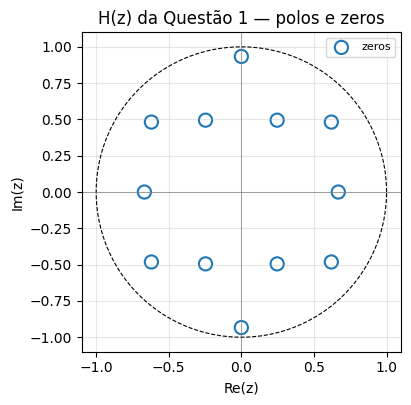

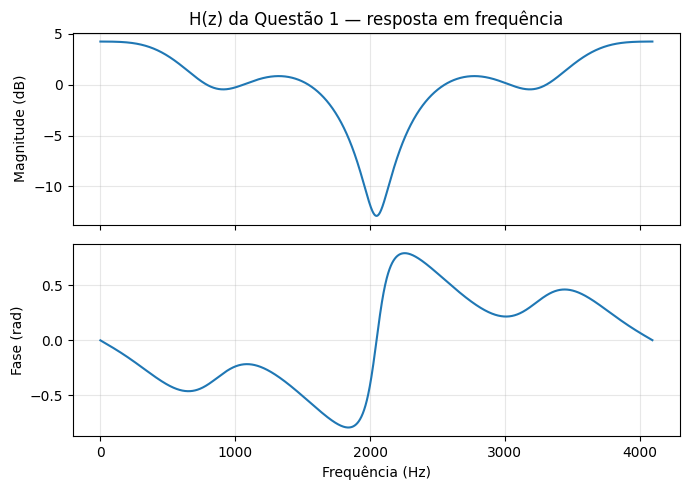

(array([0.000e+00, 2.000e+00, 4.000e+00, ..., 4.090e+03, 4.092e+03,
        4.094e+03]),
 array([1.6305    +0.j        , 1.63049752-0.0023197j ,
        1.63049007-0.0046395j , ..., 1.63047765+0.00695948j,
        1.63049007+0.0046395j , 1.63049752+0.0023197j ]))

In [7]:
b1 = np.zeros(13)
b1[0] = 1.0
b1[2] = 0.49
b1[6] = 0.2401
b1[8] = -0.0576
b1[10] = -0.0282
b1[12] = -0.0138
a1 = np.array([1.0])

plotar_polos_zeros(b1, a1, "H(z) da Questão 1 — polos e zeros")
plotar_resposta_frequencia(b1, a1, "H(z) da Questão 1 — resposta em frequência", fs=fs_handel)

## Questão 2 — Resposta de H(z) ao sinal de áudio


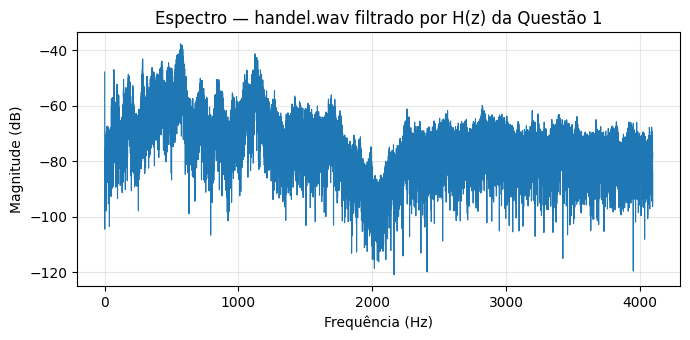

Sinal filtrado (Questão 1):


In [8]:
y1 = aplicar_sistema(b1, a1, x_handel)
calculate_spectrum(y1, fs_handel, titulo="Espectro — handel.wav filtrado por H(z) da Questão 1")
print("Sinal filtrado (Questão 1):")
tocar(y1, fs_handel)

## Questão 3 — Filtro de recuperação do sinal original

Recuperação por inversão no domínio da frequência (Seção de Setup),
que evita problemas de estabilidade caso H(z) tenha zeros fora do
círculo unitário. O diagrama de polos/zeros do inverso *ideal*
G(z) = 1/H(z) também é mostrado — polos de G(z) = zeros de H(z): se
algum estiver fora do círculo unitário, a inversão causal direta no
tempo seria instável, justificando o uso da abordagem em frequência.


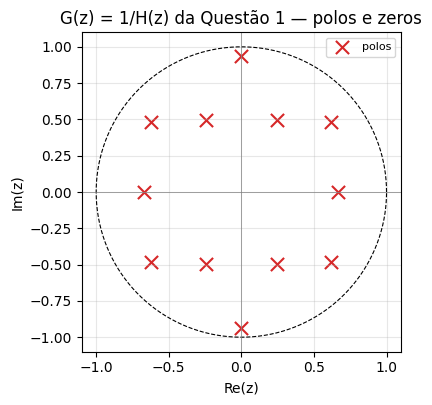

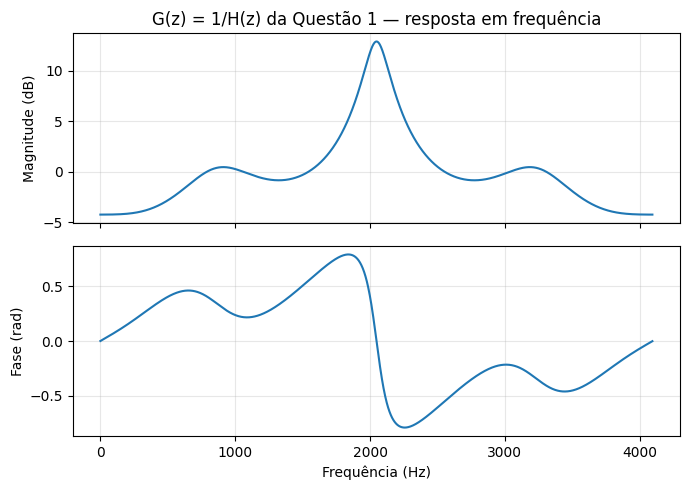

(array([0.000e+00, 2.000e+00, 4.000e+00, ..., 4.090e+03, 4.092e+03,
        4.094e+03]),
 array([0.6133088 +0.j        , 0.61330849+0.00087255j,
        0.61330757+0.00174514j, ..., 0.61330603-0.00261781j,
        0.61330757-0.00174514j, 0.61330849-0.00087255j]))

In [9]:
# Polos/zeros e resposta em frequência do inverso ideal G(z) = 1/H(z)
# (numerador e denominador trocados em relação a H(z))
plotar_polos_zeros(a1, b1, "G(z) = 1/H(z) da Questão 1 — polos e zeros")
plotar_resposta_frequencia(a1, b1, "G(z) = 1/H(z) da Questão 1 — resposta em frequência", fs=fs_handel)

Questão 3 (recuperação de H(z) da Q1) -> MSE = 0.000000 | SNR = 49.09 dB | correlação = 1.0000


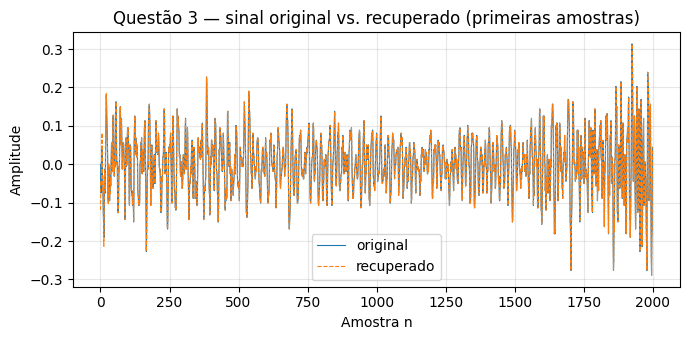

Sinal recuperado (Questão 3):


In [10]:
x_rec1 = recuperar_dominio_frequencia(y1, b1, a1, fs_handel)
avaliar_recuperacao(x_handel, x_rec1, rotulo="Questão 3 (recuperação de H(z) da Q1)")

plt.figure(figsize=(7, 3.5))
n_janela = min(2000, len(x_handel))
plt.plot(x_handel[:n_janela], label="original", linewidth=0.8)
plt.plot(x_rec1[:n_janela], label="recuperado", linewidth=0.8, linestyle="--")
plt.xlabel("Amostra n")
plt.ylabel("Amplitude")
plt.title("Questão 3 — sinal original vs. recuperado (primeiras amostras)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Sinal recuperado (Questão 3):")
tocar(x_rec1, fs_handel)

## Questão 4 — Sistemas comb H(z) = (1 − z⁻ᴸ) / (1 − a z⁻ᴸ)

Para a ∈ {0.7, 0.9} e L ∈ {1, 4, 10}: resposta em frequência e
diagrama de polos e zeros de cada um dos 6 sistemas.


In [11]:
def construir_comb(a_param, L):
    """H(z) = (1 - z^-L) / (1 - a*z^-L)."""
    b = np.zeros(L + 1)
    b[0] = 1.0
    b[L] = -1.0
    a = np.zeros(L + 1)
    a[0] = 1.0
    a[L] = -a_param
    return b, a


VALORES_A = [0.7, 0.9]
VALORES_L = [1, 4, 10]

sistemas_comb = {}
for a_param in VALORES_A:
    for L in VALORES_L:
        chave = f"a={a_param}, L={L}"
        sistemas_comb[chave] = construir_comb(a_param, L)

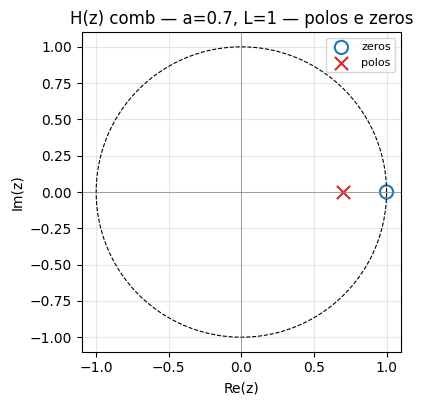

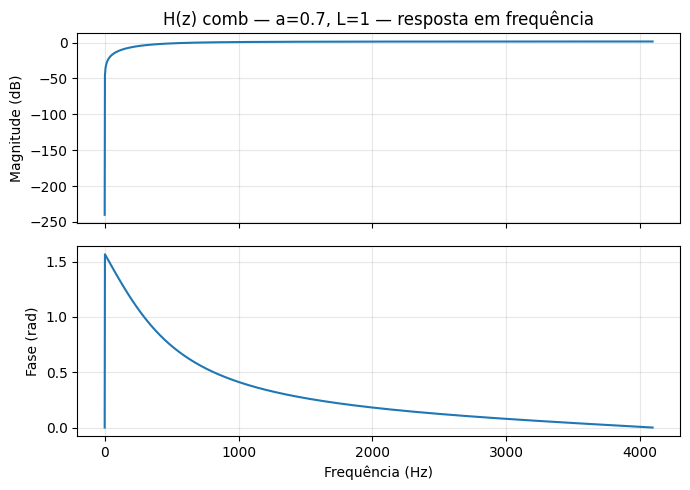

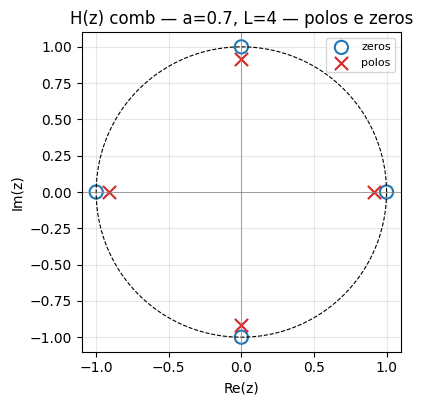

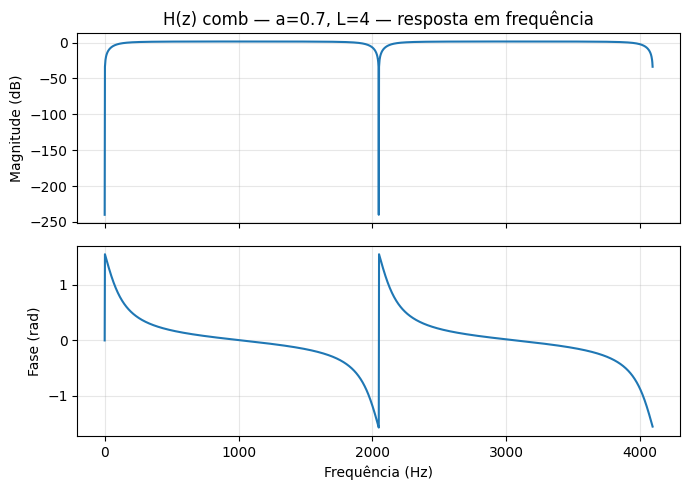

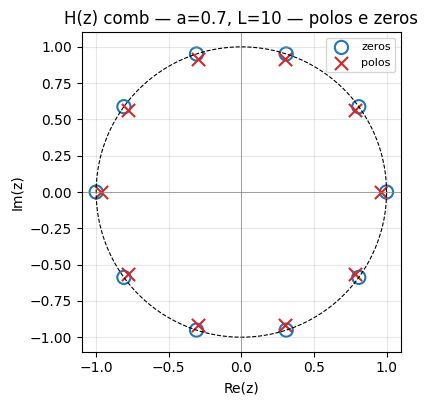

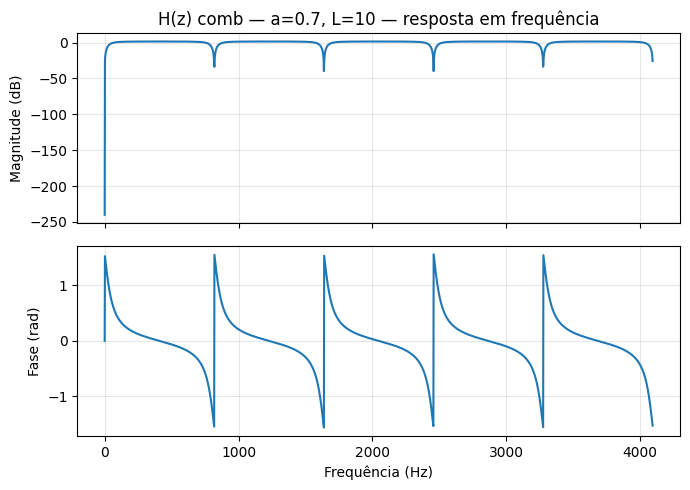

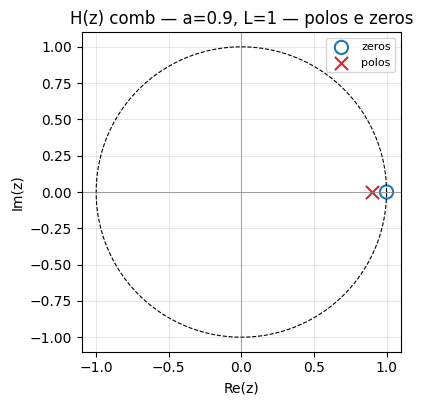

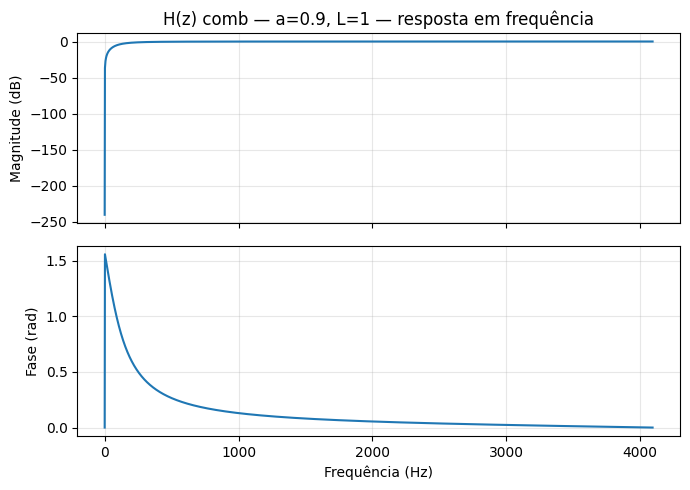

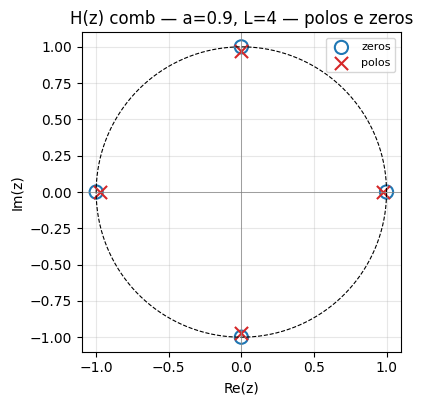

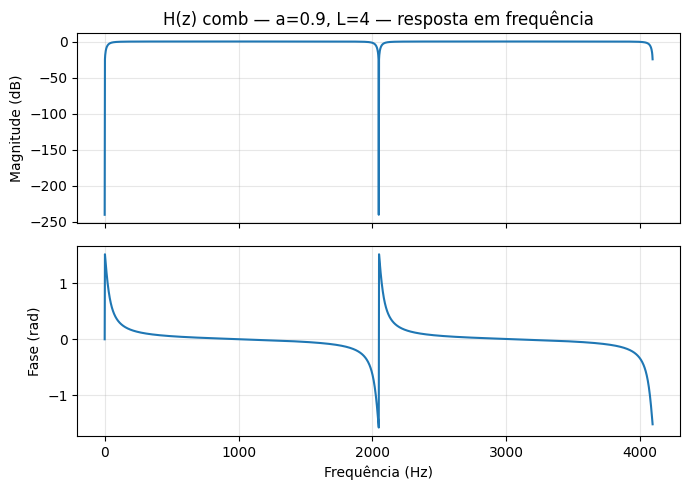

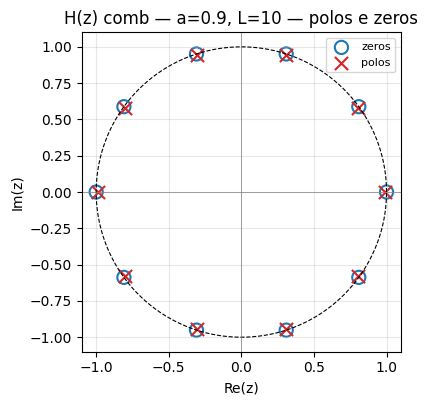

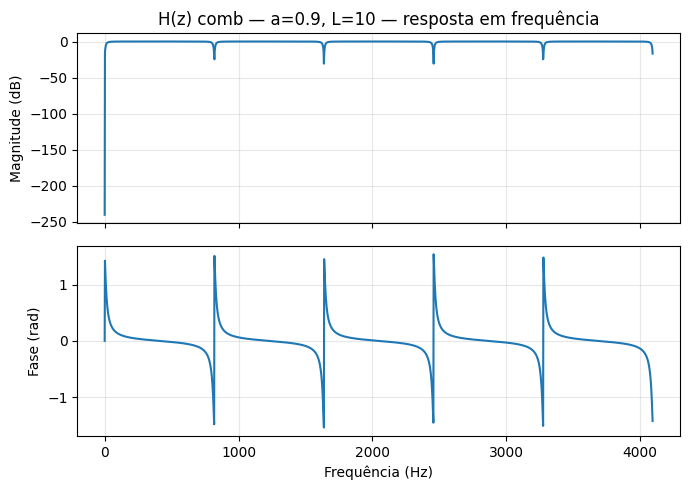

In [12]:
for chave, (b, a) in sistemas_comb.items():
    plotar_polos_zeros(b, a, f"H(z) comb — {chave} — polos e zeros")
    plotar_resposta_frequencia(b, a, f"H(z) comb — {chave} — resposta em frequência", fs=fs_handel)

## Questão 5 — Resposta dos sistemas da Questão 4 ao sinal de áudio


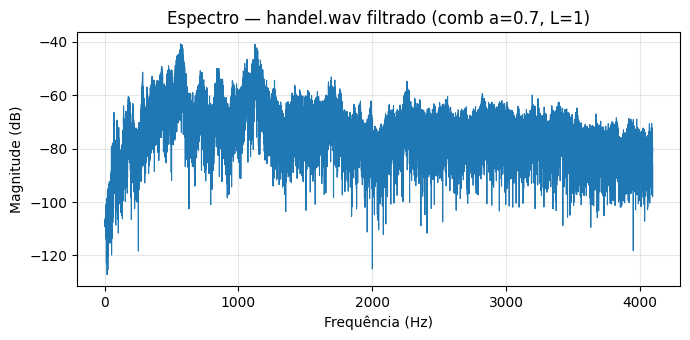

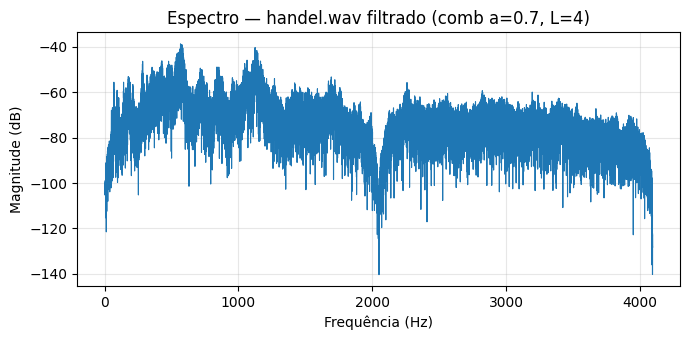

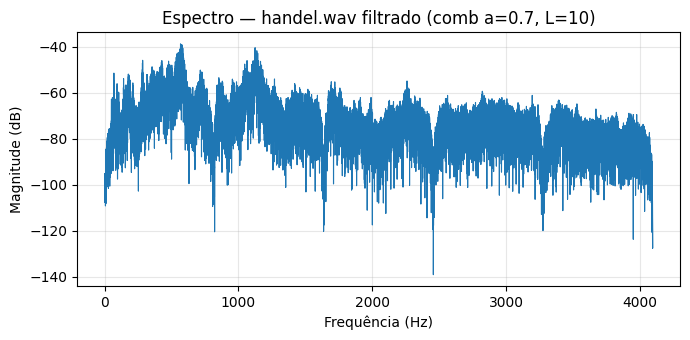

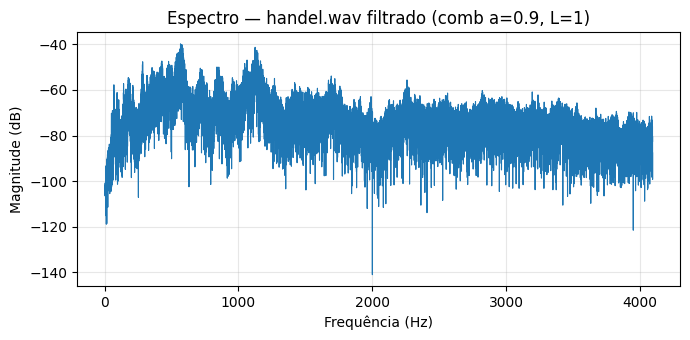

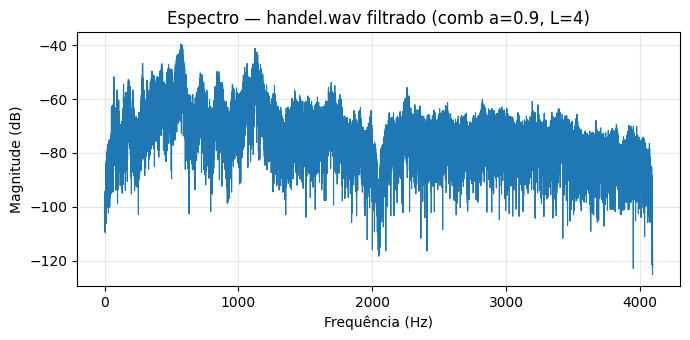

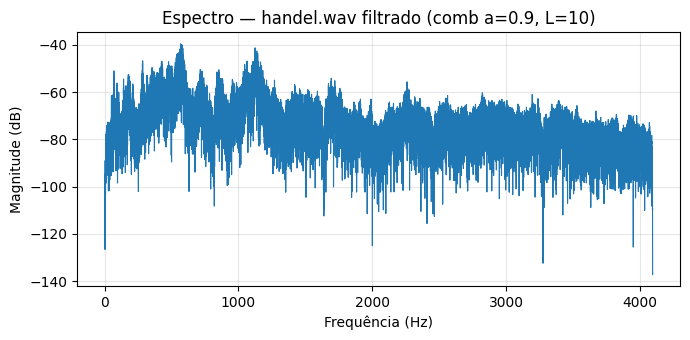

In [13]:
respostas_comb = {}
for chave, (b, a) in sistemas_comb.items():
    y = aplicar_sistema(b, a, x_handel)
    respostas_comb[chave] = y
    calculate_spectrum(y, fs_handel, titulo=f"Espectro — handel.wav filtrado (comb {chave})")

In [14]:
for chave, y in respostas_comb.items():
    print(f"Sinal filtrado — comb {chave}:")
    tocar(y, fs_handel)

Sinal filtrado — comb a=0.7, L=1:


Sinal filtrado — comb a=0.7, L=4:


Sinal filtrado — comb a=0.7, L=10:


Sinal filtrado — comb a=0.9, L=1:


Sinal filtrado — comb a=0.9, L=4:


Sinal filtrado — comb a=0.9, L=10:


## Questão 6 — Filtros de recuperação para os sistemas da Questão 4

Assim como na Questão 3, o numerador de cada H(z) comb tem zeros
exatamente sobre o círculo unitário (nas L raízes L-ésimas da
unidade) — logo o inverso ideal G(z) = 1/H(z) tem polos exatamente
sobre o círculo unitário, tornando a inversão causal no tempo
marginalmente instável nessas frequências. A recuperação por
inversão no domínio da frequência, com regularização, é usada para
contornar esse problema.


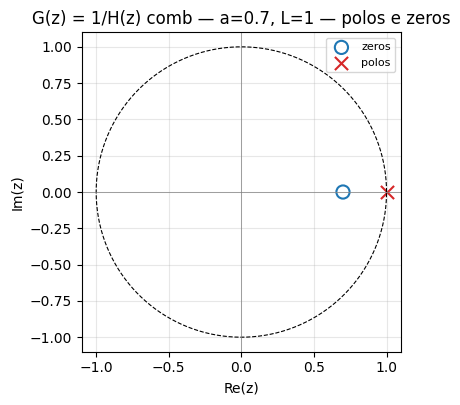

Questão 6 (comb a=0.7, L=1) -> MSE = 0.000010 | SNR = 35.76 dB | correlação = 0.9999


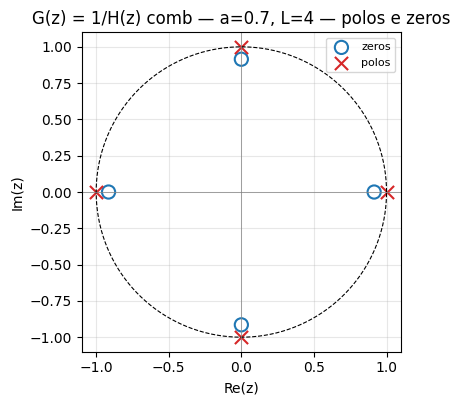

Questão 6 (comb a=0.7, L=4) -> MSE = 0.000011 | SNR = 35.47 dB | correlação = 0.9999


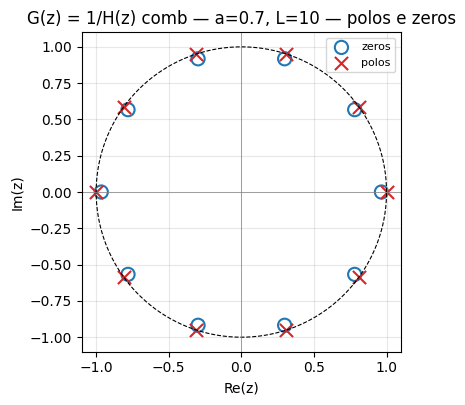

Questão 6 (comb a=0.7, L=10) -> MSE = 0.000028 | SNR = 31.42 dB | correlação = 0.9997


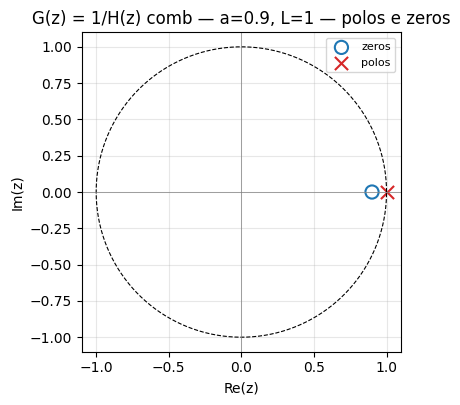

Questão 6 (comb a=0.9, L=1) -> MSE = 0.000009 | SNR = 36.35 dB | correlação = 1.0000


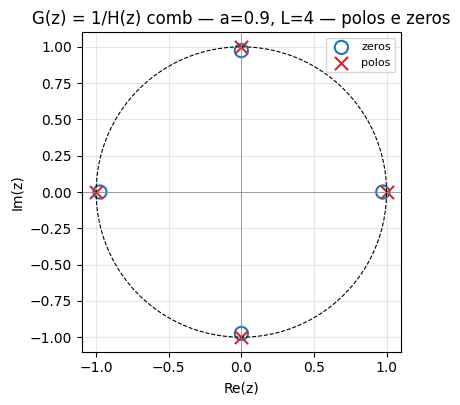

Questão 6 (comb a=0.9, L=4) -> MSE = 0.000008 | SNR = 36.73 dB | correlação = 1.0000


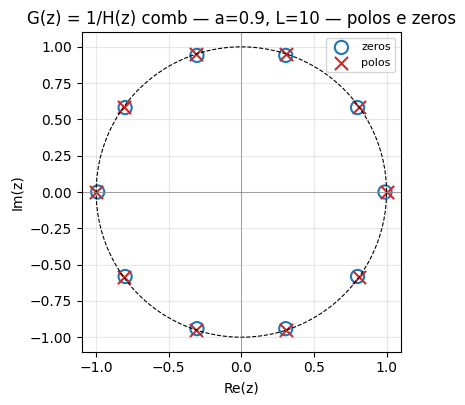

Questão 6 (comb a=0.9, L=10) -> MSE = 0.000014 | SNR = 34.35 dB | correlação = 0.9999


In [15]:
recuperados_comb = {}
for chave, (b, a) in sistemas_comb.items():
    plotar_polos_zeros(a, b, f"G(z) = 1/H(z) comb — {chave} — polos e zeros")

    y = respostas_comb[chave]
    x_rec = recuperar_dominio_frequencia(y, b, a, fs_handel)
    recuperados_comb[chave] = x_rec
    avaliar_recuperacao(x_handel, x_rec, rotulo=f"Questão 6 (comb {chave})")

In [16]:
for chave, x_rec in recuperados_comb.items():
    print(f"Sinal recuperado — comb {chave}:")
    tocar(x_rec, fs_handel)

Sinal recuperado — comb a=0.7, L=1:


Sinal recuperado — comb a=0.7, L=4:


Sinal recuperado — comb a=0.7, L=10:


Sinal recuperado — comb a=0.9, L=1:


Sinal recuperado — comb a=0.9, L=4:


Sinal recuperado — comb a=0.9, L=10:


## Questão 7 — Aproximações FIR dos filtros de recuperação

Para os filtros de recuperação das Questões 3 e 6, projeta-se uma
aproximação FIR causal e estável, por mínimos quadrados, em algumas
ordens diferentes, avaliando a relação entre a ordem do filtro e a
qualidade do sinal recuperado.


In [17]:
ORDENS_FIR = [8, 32, 128, 512]

# Sistemas a serem invertidos por FIR: H(z) da Questão 1 + os 6 combs da Questão 4
sistemas_para_fir = {"Q1": (b1, a1, y1)}
for chave, (b, a) in sistemas_comb.items():
    sistemas_para_fir[f"comb {chave}"] = (b, a, respostas_comb[chave])

In [18]:
resultados_fir = {}  # {sistema: {ordem: (mse, snr_db, correlacao)}}

for nome_sistema, (b, a, y) in sistemas_para_fir.items():
    h = obter_resposta_impulso(b, a, comprimento=2000)
    resultados_fir[nome_sistema] = {}

    for ordem in ORDENS_FIR:
        g, atraso = projetar_fir_inverso_lsq(h, ordem)
        x_rec_fir = aplicar_fir_inverso(y, g, atraso, comprimento_alvo=len(x_handel))
        mse, snr_db, corr = avaliar_recuperacao(
            x_handel, x_rec_fir, rotulo=f"{nome_sistema} — FIR ordem {ordem}"
        )
        resultados_fir[nome_sistema][ordem] = (mse, snr_db, corr)

Q1 — FIR ordem 8 -> MSE = 0.001299 | SNR = 14.72 dB | correlação = 0.9835
Q1 — FIR ordem 32 -> MSE = 0.000143 | SNR = 24.31 dB | correlação = 0.9982
Q1 — FIR ordem 128 -> MSE = 0.000017 | SNR = 33.56 dB | correlação = 0.9998
Q1 — FIR ordem 512 -> MSE = 0.000062 | SNR = 27.93 dB | correlação = 0.9992
comb a=0.7, L=1 — FIR ordem 8 -> MSE = 0.002582 | SNR = 11.74 dB | correlação = 0.9661
comb a=0.7, L=1 — FIR ordem 32 -> MSE = 0.000526 | SNR = 18.65 dB | correlação = 0.9936
comb a=0.7, L=1 — FIR ordem 128 -> MSE = 0.000055 | SNR = 28.41 dB | correlação = 0.9994
comb a=0.7, L=1 — FIR ordem 512 -> MSE = 0.000071 | SNR = 27.36 dB | correlação = 0.9992
comb a=0.7, L=4 — FIR ordem 8 -> MSE = 0.000840 | SNR = 16.61 dB | correlação = 0.9896
comb a=0.7, L=4 — FIR ordem 32 -> MSE = 0.000372 | SNR = 20.15 dB | correlação = 0.9955
comb a=0.7, L=4 — FIR ordem 128 -> MSE = 0.000076 | SNR = 27.04 dB | correlação = 0.9991
comb a=0.7, L=4 — FIR ordem 512 -> MSE = 0.000075 | SNR = 27.08 dB | correlação = 

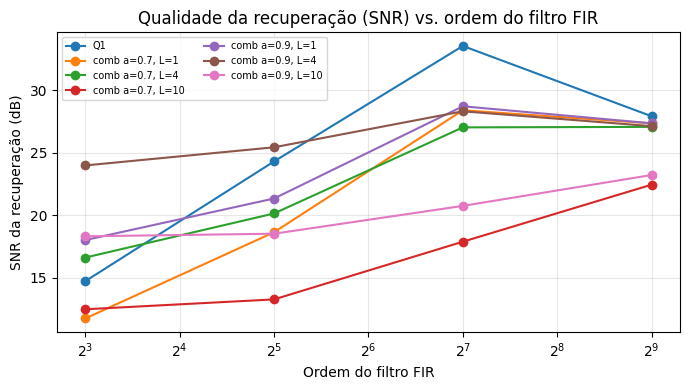

In [19]:
# Relação entre ordem do filtro FIR e qualidade da recuperação (SNR)
plt.figure(figsize=(7, 4))
for nome_sistema, resultados in resultados_fir.items():
    ordens = list(resultados.keys())
    snrs = [resultados[o][1] for o in ordens]
    plt.plot(ordens, snrs, marker="o", label=nome_sistema)

plt.xlabel("Ordem do filtro FIR")
plt.ylabel("SNR da recuperação (dB)")
plt.title("Qualidade da recuperação (SNR) vs. ordem do filtro FIR")
plt.xscale("log", base=2)
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Exemplo de audição: recuperação via FIR de ordem mais alta para a Questão 1
g, atraso = projetar_fir_inverso_lsq(obter_resposta_impulso(b1, a1, 2000), ORDENS_FIR[-1])
x_rec1_fir = aplicar_fir_inverso(y1, g, atraso, comprimento_alvo=len(x_handel))
print(f"Sinal recuperado via FIR de ordem {ORDENS_FIR[-1]} (Questão 1):")
tocar(x_rec1_fir, fs_handel)

Sinal recuperado via FIR de ordem 512 (Questão 1):
